# **HANDS - ON: LIMPIEZA DE DATOS**



Una vez visto la presentación ***Limpieza de datos***, se proporciona el siguiente ***colab*** para que **el alumnado pueda practicar** haciendo uso del lenguaje de programación ***python***.

Para este notebook, se hará uso del siguiente dataset: [enlace](https://drive.google.com/file/d/1X8v6zs9eDBVXPAQK9veDwINo4-H3mIPU/view?usp=drive_link)

De igual manera, se proporciona la **solución** de este notebook a través del siguiente [enlace](https://colab.research.google.com/drive/1yQmEO8AuICLYlBsAEA6LURzY1v_zJ2TA?usp=sharing).

## **RECOPILACIÓN DE DATOS**

La **recopilación de datos** es el **proceso de reunir y medir datos sobre un tema o fenómeno específico** que puedan ser analizados para responder preguntas de investigación, tomar decisiones informadas o comprender mejor un tema en particular. Esto implica:

*   **Seleccionar un método de recolección adecuado** (como encuestas, entrevistas, observaciones, o el uso de datos existentes).
*   **Aplicar dicho método de manera sistemática**.
*   **Registrar los resultados obtenidos**.

**Existen diversas fuentes confiables** donde puedes recopilar datos para análisis, dependiendo del tipo de información que necesites.

Algunos sitios webs que ofrecen conjuntos de datos publicos y gratuitos son:

*  [**Kaggle**](https://www.kaggle.com/datasets)
*  [**Reddit**](https://datos.cdmx.gob.mx/dataset/)
*  [**ONU**](https://data.un.org/)
*  [**OMS**](https://www.who.int/data/collections)
*  [**WB**](https://datos.bancomundial.org/)
*  [**INEGI**](https://www.inegi.org.mx/datosabiertos/)
*  [**Gobierno de México**](https://datos.gob.mx/busca/dataset)
*  [**Sistema CDMX**](https://datos.cdmx.gob.mx/dataset/)

#### **IMPORTACIÓN DE DATOS**


Existen **diferentes formas de importar datos en Google Colab**, lo que lo convierte en una herramienta versátil para el análisis y la manipulación de datos.

In [ ]:
# Importar librerías
import pandas as pd

##### **ARCHIVO LOCAL**

Para **acceder a datos almacenados localmente** en tu ordenador, puedes utilizar las siguientes funciones de ***Pandas***, dependiendo del formato de archivo en el que se encuentren tus datos:


*   **Sintaxis CSV:**

```
pd.read_csv('ruta/archivo.csv')
```

*   **Sintaxis Excel:**

```
pd.read_excel('ruta/al/archivo.xlsx')
```

*   **Sintaxis JSON:**

```
pd.read_json('ruta/archivo.json')
```

Para conocer los formatos de archivos restantes a las que se pueden acceder, será necesario consultar la [documentación](https://pandas.pydata.org/docs/reference/io.html).

***Google Colaboratory*** opera en un **entorno virtualizado**, lo que implica que no tiene acceso directo al sistema de archivos de tu máquina local. Por lo tanto, para trabajar con archivos almacenados en tu ordenador, es necesario acudir a otras alternativass.

*   Importar datos directamente desde **Google Colaboratory**, aunque esta opcióN solo es temporal.

*   Utilizar otros **entornos de almacenamiento** para cargarlos al entorno de ***Colab***.

In [ ]:
# Importar datos desde Google Colab
# El archivo se borra al terminar sesión
# youtube_dirty = pd.read_csv('/content/youtube_dirty.csv')
# youtube_dirty.head()

##### **GITHUB**

Si los datos están almacenados en ***GitHub***, basta con tener la liga que proporciona la opción **raw** dentro del repositorio para acceder a ellos.


In [32]:
# Importar datos desde GitHub
yt_dirty = pd.read_csv('https://raw.githubusercontent.com/Geovanni-ZM/datasets/refs/heads/main/youtube_dirty.csv')
yt_dirty.head()


,video_id,título,categoría,views,likes,dislikes,comentarios,duración_min,fecha_publicación
0,1,Título 1###,musica,NaN,NaN,21,8790,127,2024/07/02
1,2,Título 2@@@,películas,247904.0,15579.0,211,4775,63,2.13.2022
2,3,NaN,comedia!!!,3073.0,14780.0,1095,9847,55,07-06-2016
3,4,Título 4,gaming,268858.0,2691.0,4420,7614,78,12.3.2017
4,5,Título 5,Gaming!!!,162893.0,16521.0,2294,6508,143,2023-11-24


##### **GOOGLE DRIVE**

Si los datos están almacenados en ***Google Drive***, se puede montar en ***Colab*** y acceder a ellos. Para ello se puede seguir la siguiente sintaxis:

```
from google.colab import drive
drive.mount('/content/drive')
```

De manera posterior, el procedimeinto para **acceder a los datos es igual a la formas anteriores**.

In [ ]:
# Montar Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# Importar datos desde Google Drive
# ruta_drive = '/content/drive/MyDrive/datasets/youtube_dirty.csv'
# drive_dirty = pd.read_csv(ruta_drive)
# drive_dirty.head()

Cuando la forma anterior no funcione debido a que **Google Drive cambie el tipo de dato** del archivo, existen otras alternativas de acceder a los datos.

## **SANEAMIENTO DE DATOS**

**El saneamiento es la etapa donde se busca asegurar la integridad el conjunto de datos.** Un dataset crudo suele contener inconsistencias que pueden sesgar nuestros análisis.

Cuando se comienza el saneamiento de datos, **se busca limpiar del dataset en la corrección de valores nulos (vacíos)**.

In [33]:
# Ver tipos de datos
yt_dirty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   video_id           308 non-null    int64  
 1   título             282 non-null    object 
 2   categoría          283 non-null    object 
 3   views              284 non-null    float64
 4   likes              284 non-null    float64
 5   dislikes           308 non-null    int64  
 6   comentarios        308 non-null    int64  
 7   duración_min       308 non-null    int64  
 8   fecha_publicación  308 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 21.8+ KB


In [ ]:
# Verificar valores nulos por columna
print(yt_dirty.isnull().sum())

video_id              0
título               26
categoría            25
views                24
likes                24
dislikes              0
comentarios           0
duración_min          0
fecha_publicación     0
dtype: int64


In [ ]:
# Observar los primeros 10 registros
yt_dirty.head(10)

,video_id,título,categoría,views,likes,dislikes,comentarios,duración_min,fecha_publicación
0,1,Título 1###,musica,NaN,NaN,21,8790,127,2024/07/02
1,2,Título 2@@@,películas,247904.0,15579.0,211,4775,63,2.13.2022
2,3,NaN,comedia!!!,3073.0,14780.0,1095,9847,55,07-06-2016
3,4,Título 4,gaming,268858.0,2691.0,4420,7614,78,12.3.2017
4,5,Título 5,Gaming!!!,162893.0,16521.0,2294,6508,143,2023-11-24
5,6,Título 6@@@,películas,42160.0,10721.0,3547,9033,58,8.27.2025
6,7,Título 7,música,90723.0,6461.0,2057,5150,219,2021-05-04
7,8,Título 8!!!,Comedia!!!,166255.0,10284.0,300408,7206,115,2019/10/15
8,9,Título 9!!!,NaN,94776.0,19339.0,1855,2847,207,7.18.2017
9,10,Título 10???,Musica???,-1.0,17151.0,458,9632,164,2023/08/26


### **VARIABLES DE TEXTO**

La **limpieza de datos para columnas de texto** se separa porque este tipo de datos presenta desafíos y requerimientos de preprocesamiento únicos. A diferencia de los datos numéricos, las columnas de texto pueden contener:


*   **Valores faltantes :** Se deben imputar o eliminar.

*   **Errores tipográficos y variaciones:** Palabras mal escritas, uso inconsistente de mayúsculas/minúsculas, abreviaturas, etc.

*   **Caracteres especiales y símbolos:** Signos de puntuación, emojis, caracteres no alfanuméricos que no aportan valor al análisis.

*   **Espacios extra o formatos inconsistentes:** Espacios al inicio/final, múltiples espacios entre palabras.

*   **Valores semánticamente similares:** Palabras que significan lo mismo pero están escritas de forma diferente.

#### **IMPUTACIÓN**

La **imputación de datos** es el proceso de reemplazar los valores faltantes o nulos en un conjunto de datos con valores sustitutos.

El objetivo principal de la imputación es **mantener la integridad del conjunto de datos y evitar la pérdida de información** que ocurriría si simplemente se eliminaran las filas o columnas con valores faltantes.

In [34]:
# Verificar valores nulos por columna de texto
columnas_texto =['título', 'categoría','fecha_publicación']
print(yt_dirty[columnas_texto].isnull().sum())

título               26
categoría            25
fecha_publicación     0
dtype: int64


In [35]:
# Visualizar los primeros 10 registros nulos
print(yt_dirty[yt_dirty['categoría'].isnull()].head(10))
# print(yt_dirty[yt_dirty['título'].isnull()].head(10))

    video_id          título categoría     views    likes  dislikes  \
8          9    Título 9!!!        NaN   94776.0  19339.0      1855   
12        13             NaN       NaN   35750.0  15682.0      1881   
22        23     Título 23         NaN  184431.0   3302.0      2232   
29        30   Título 30###        NaN  166500.0   7327.0      2890   
32        33             NaN       NaN   93055.0   8677.0      1287   
44        45   Título 45???        NaN  271669.0  15405.0    300408   
45        46   Título 46@@@        NaN       NaN      NaN       596   
61        62     Título 62         NaN  267248.0  14697.0      2043   
70        71   Título 71???        NaN  100741.0  19050.0    300408   
85        86     Título 86         NaN   36915.0  16017.0      3262   

    comentarios  duración_min fecha_publicación  
8          2847           207         7.18.2017  
12         4607           178        2017/11/02  
22         9615            46        2020/12/06  
29         2882   

In [36]:
# Imputación de datos por nueva categoría
yt_dirty['categoría'] = yt_dirty['categoría'].fillna('Sin categoría')
yt_dirty['título'] = yt_dirty['título'].fillna('Sin título')

#### **NORMALIZACIÓN**

En ocasiones, ciertos registros de texto suelen tener **símbolos especiales** como `!!!`, `@@@`, espacios extra, etc. Con el uso de **Expresiones Regulares (REGEX) se limpia el texto de los símbolos expeciales.**

In [37]:
# Observar valores únicos por columna de texto
# print(yt_dirty['título'].unique())
print(yt_dirty['categoría'].unique())
print(yt_dirty['categoría'].nunique()) # Número de categorías únicas
# print(yt_dirty['fecha_publicación'].unique())

[' musica  ' ' películas  ' ' comedia!!! ' ' gaming  ' ' Gaming!!! '
 ' música ' ' Comedia!!! ' 'Sin categoría' ' Musica??? ' ' Tecnología??? '
 ' Educación!!! ' ' Peliculas  ' ' Comedia??? ' ' Peliculas??? '
 ' Tecnologia??? ' ' Deportes@@@ ' ' películas??? ' ' gaming@@@ '
 ' Tecnología!!! ' ' noticias!!! ' ' educacion  ' ' Películas  '
 ' Gaming??? ' ' tecnología  ' ' deportes  ' ' tecnología@@@ '
 ' Peliculas### ' ' Películas@@@ ' ' Noticias@@@ ' ' comedia '
 ' peliculas ' ' comedia  ' ' noticias### ' ' educación ' ' Comedia### '
 ' Peliculas ' ' peliculas  ' ' deportes ' ' Noticias ' ' música??? '
 ' tecnologia ' ' Deportes ' ' comedia### ' ' Educación??? '
 ' Noticias??? ' ' educacion!!! ' ' educacion ' ' noticias ' ' Musica@@@ '
 ' Deportes??? ' ' Gaming### ' ' deportes### ' ' gaming??? '
 ' tecnología!!! ' ' educacion### ' ' Deportes### ' ' noticias  '
 ' Películas### ' ' peliculas??? ' ' Peliculas!!! ' ' Gaming  '
 ' Noticias!!! ' ' deportes@@@ ' ' musica??? ' ' peliculas!!! '


In [38]:
import re

def limpiar_texto(texto):
    if pd.isna(texto): return texto
    texto = re.sub(r"[^a-zA-ZáéíóúÁÉÍÓÚñÑ\s]", "", str(texto))
    return texto.strip().lower()

In [39]:
# Aplicar limpieza a columnas con texto
yt_dirty['título'] = yt_dirty['título'].apply(limpiar_texto)
yt_dirty['categoría'] = yt_dirty['categoría'].apply(limpiar_texto)
yt_dirty['categoría'].unique()

array(['musica', 'películas', 'comedia', 'gaming', 'música',
       'sin categoría', 'tecnología', 'educación', 'peliculas',
       'tecnologia', 'deportes', 'noticias', 'educacion'], dtype=object)

In [40]:
# Observar cambios en los valores únicos
print(yt_dirty['título'].unique())
print(yt_dirty['categoría'].unique())

['título' 'sin título']
['musica' 'películas' 'comedia' 'gaming' 'música' 'sin categoría'
 'tecnología' 'educación' 'peliculas' 'tecnologia' 'deportes' 'noticias'
 'educacion']


In [41]:
# Corregir detalles de texto adicionales
reemplazos = {
    'musica': 'música',
    'tecnologia':'tecnología',
    'educacion':'educación',
    'peliculas':'películas'
}

yt_dirty['categoría'] = yt_dirty['categoría'].replace(reemplazos)
yt_dirty['categoría'].unique()

array(['música', 'películas', 'comedia', 'gaming', 'sin categoría',
       'tecnología', 'educación', 'deportes', 'noticias'], dtype=object)

In [ ]:
# Cambio de tipo de dato
yt_dirty['título'] = yt_dirty['título'].astype('category')
yt_dirty['categoría'] = yt_dirty['categoría'].astype('category')

In [42]:
# Verificar cambio de típos de dato
yt_dirty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   video_id           308 non-null    int64  
 1   título             308 non-null    object 
 2   categoría          308 non-null    object 
 3   views              284 non-null    float64
 4   likes              284 non-null    float64
 5   dislikes           308 non-null    int64  
 6   comentarios        308 non-null    int64  
 7   duración_min       308 non-null    int64  
 8   fecha_publicación  308 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 21.8+ KB


#### **TRANSFORMACIÓN DE FECHAS**

Las fechas suelen ser uno de los tipos de datos más problemáticos debido a la multitud de formatos en los que pueden presentarse. La **transformación y estandarización de fechas** es crucial.

In [43]:
# Ver los primeros 10 registros
yt_dirty['fecha_publicación'].head(10)

,fecha_publicación
0,2024/07/02
1,2.13.2022
2,07-06-2016
3,12.3.2017
4,2023-11-24
5,8.27.2025
6,2021-05-04
7,2019/10/15
8,7.18.2017
9,2023/08/26


In [44]:
# Cambio de tipo de dato y normalización de formato
yt_dirty['fecha_publicación'] = pd.to_datetime(yt_dirty['fecha_publicación'], format='mixed')
yt_dirty['fecha_publicación'].head(10)

,fecha_publicación
0,2024-07-02
1,2022-02-13
2,2016-07-06
3,2017-12-03
4,2023-11-24
5,2025-08-27
6,2021-05-04
7,2019-10-15
8,2017-07-18
9,2023-08-26


In [45]:
# Verificar cambio de típo de dato
yt_dirty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   video_id           308 non-null    int64         
 1   título             308 non-null    object        
 2   categoría          308 non-null    object        
 3   views              284 non-null    float64       
 4   likes              284 non-null    float64       
 5   dislikes           308 non-null    int64         
 6   comentarios        308 non-null    int64         
 7   duración_min       308 non-null    int64         
 8   fecha_publicación  308 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(4), object(2)
memory usage: 21.8+ KB


### **VARIABLES NUMÉRICAS**

La **limpieza de datos para columnas numéricas** también se maneja por separado debido a la naturaleza distintiva de los problemas que pueden surgir con este tipo de datos y las metodologías específicas para abordarlos. Las columnas numéricas suelen presentar:

*   **Valores faltantes :** Se deben imputar o eliminar.

*   **Valores atípicos:** Datos que se desvían significativamente del patrón general, los cuales pueden ser errores o representaciones de fenómenos raros.

*   **Inconsistencias de escala:** Rangos de valores muy diferentes entre columnas. Esto se aborda con normalización o estandarización.

*   **Errores de entrada o lógica:** Valores negativos donde solo positivos son posibles, valores extremadamente grandes o pequeños que indican fallas en la recolección.



In [46]:
# Importar librerías de visualización
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [47]:
# Ver tipos de datos
yt_dirty.dtypes

,0
video_id,int64
título,object
categoría,object
views,float64
likes,float64
dislikes,int64
comentarios,int64
duración_min,int64
fecha_publicación,datetime64[ns]


In [48]:
# Verificar valores nulos por columna numérica
columnas_numericas = ['views', 'likes', 'dislikes', 'comentarios', 'duración_min']
print(yt_dirty[columnas_numericas].isnull().sum())

views           24
likes           24
dislikes         0
comentarios      0
duración_min     0
dtype: int64


#### **IMPUTACIÓN Y NORMALIZACIÓN**

En la fase de **imputación y normalización para variables numéricas**, el objetivo es asegurar que estos datos sean consistentes, completos y adecuados para el análisis.

Estas acciones son cruciales para mantener la integridad del dataset y garantizar que los análisis posteriores no se vean afectados por datos faltantes o erróneos.

In [49]:
# Ver resumen estadístico de las columnas con nulos
col_num_null = ['views', 'likes']
yt_dirty[col_num_null].describe()

,views,likes
count,284.000000,2.840000e+02
mean,137926.799296,6.785967e+05
std,96538.282338,2.500358e+06
min,-1.000000,9.700000e+01
25%,48809.250000,5.389750e+03
50%,129257.000000,1.129900e+04
75%,229829.500000,1.602150e+04
max,299408.000000,9.999999e+06


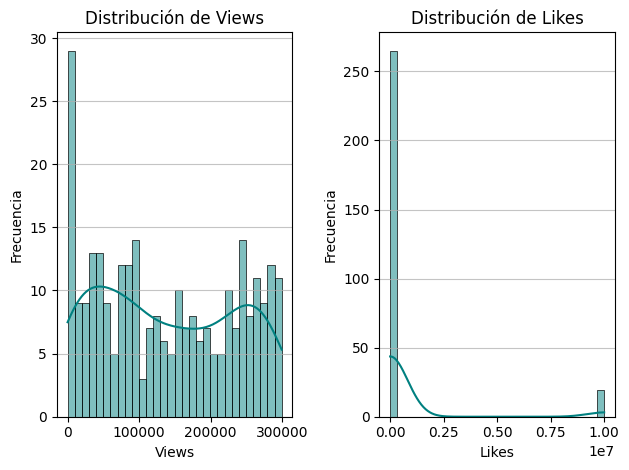

In [52]:
# Observar distribución de las columnas con nulos
columnas_a_graficar = ['views', 'likes']

for i, col in enumerate(columnas_a_graficar,1):
    plt.subplot(1, 2, i)
    sns.histplot(data=yt_dirty[col], bins=30, kde=True, color = 'teal')
    plt.title(f'Distribución de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

In [59]:
# Calcular media y desviación estándar de las columnas con nulos
media_views = yt_dirty['views'].mean()
std_views = yt_dirty['views'].std()

media_likes = yt_dirty['likes'].mean()
std_likes = yt_dirty['likes'].std()

lim_sup_views = media_views + std_views
lim_inf_views = media_views - std_views

lim_sup_likes = media_likes + std_likes
lim_inf_likes = media_likes - std_likes

configuracion_views = [(media_views, 'blue'), (lim_sup_views, 'red'), (lim_inf_views, 'red')]
configuracion_likes = [(media_likes, 'blue'), (lim_sup_likes, 'red'), (lim_inf_likes, 'red')]

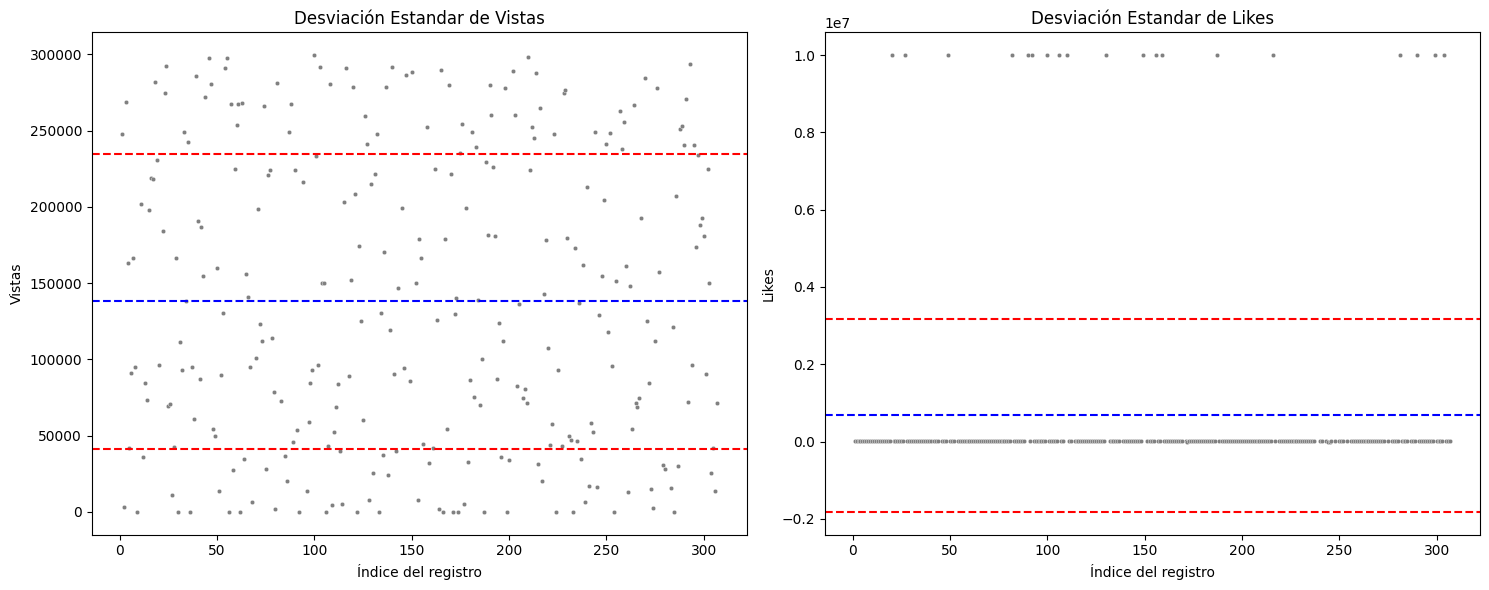

In [60]:
# Observar distribución de las columnas con nulos

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # Los datos se alejan de la media
sns.scatterplot(x=range(len(yt_dirty)), y=yt_dirty['views'], s=10, color='gray')
plt.title('Desviación Estandar de Vistas')
plt.xlabel('Índice del registro')
plt.ylabel('Vistas')
for dato, color in configuracion_views:
    plt.axhline(y=dato, color=color, linestyle='--')

plt.subplot(1, 2, 2) # Los datos se alejan de la media y se polarizan en dos extremos
sns.scatterplot(x=range(len(yt_dirty)), y=yt_dirty['likes'], s=10, color='gray')
plt.title('Desviación Estandar de Likes')
plt.xlabel('Índice del registro')
plt.ylabel('Likes')
for dato, color in configuracion_likes:
    plt.axhline(y=dato, color=color, linestyle='--')

plt.tight_layout()
plt.show()

In [61]:
# Imputación de datos

# Debido a los outliers y la alejanía hacia la media, la MTC será la mediana
yt_dirty['views'] = yt_dirty['views'].fillna(yt_dirty['views'].median())
yt_dirty['likes'] = yt_dirty['likes'].fillna(yt_dirty['likes'].median())

yt_dirty.loc[yt_dirty['views'] < 0, 'views'] = yt_dirty['views'].median() # No existen vistas negativas, imputar con la mediana
print(yt_dirty.isnull().sum())

video_id             0
título               0
categoría            0
views                0
likes                0
dislikes             0
comentarios          0
duración_min         0
fecha_publicación    0
dtype: int64


In [62]:
# Cambio de tipo de dato
yt_dirty['views'] = yt_dirty['views'].astype('int')
yt_dirty['likes'] = yt_dirty['likes'].astype('int')

In [63]:
# Ver tipos de datos
yt_dirty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   video_id           308 non-null    int64         
 1   título             308 non-null    object        
 2   categoría          308 non-null    object        
 3   views              308 non-null    int64         
 4   likes              308 non-null    int64         
 5   dislikes           308 non-null    int64         
 6   comentarios        308 non-null    int64         
 7   duración_min       308 non-null    int64         
 8   fecha_publicación  308 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(6), object(2)
memory usage: 21.8+ KB


In [64]:
# Crear dataset final
yt_clean = yt_dirty.copy()
yt_clean.to_csv('youtube_clean.csv', index=False)

## **CHALLENGE: ALOJAMIENTO AIRBNB CDMX**

Una vez visto el ***Hands - On: Limpieza de datos***, se presentan las siguientes actividades para que el alumnado pueda repasar y reforzar lo aprendido dentro de la clase.

Para este notebook, se hará uso del siguiente dataset: [enlace](https://drive.google.com/file/d/1F3WOQnwg5jFZD7rnW3IiTh0ObKCnSODd/view?usp=drive_link)

Dentro de la siguiente dinámica, **se realizará un proceso completo de limpieza y preparación de datos** sobre el catálogo de alojamientos de Airbnb en la Ciudad de México, con la finalidad de garantizar la calidad e integridad de la información antes de cualquier análisis posterior. Se hará uso de **herramientas de manipulación de datos, técnicas de imputación y análisis exploratorio** a través del dataset **"airbnb_cdmx"**.

Donde los procesos a realizar son:

* **Identificación y tratamiento de valores nulos por tipo de dato**.
* **Estandarización de columnas categóricas y conversión de tipos de datos**.
* **Imputación basada en distribución y resumen estadístico**.

**IMPORTANTE:** Para su revisión, **es indispensable que los apartados anteriores se encuentren llenados con el código visto durante la sesión.**

### **INSTRUCCIONES:**

**1. Importaciones y visualización de estructura:**

* Carga las bibliotecas de Pandas, Seaborn y Matplotlib.pyplot.
* Carga el archivo *airbnb_cdmx.csv*.
* Visualiza los tipos de datos de las columnas.








In [87]:
# Importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [88]:
# Importar dataset
df_airbnb_cdmx = pd.read_csv('https://raw.githubusercontent.com/KevinMJ/Master-en-Data-Sciece-con-IA/refs/heads/main/Introducci%C3%B3n_al_an%C3%A1lisis_de_datos/Lecci%C3%B3n_4_Decisiones_con_fundamento/airbnb_cdmx.csv')

In [89]:
# Ver tipos de datos
df_airbnb_cdmx.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,float64
minimum_nights,int64


**2. Visualización de duplicados y valores nulos en columnas de texto:**

* Verifica valores nulos y la existencia de registros duplicados.
* Cuantifica los valores faltantes para las columnas de tipo texto.
* Visualiza los primeros 10 registros nulos de cada columna.

In [90]:
# Detección de duplicados y valores nulos por columna
print(f"Número de filas duplicadas: {df_airbnb_cdmx.duplicated().sum()}")
print("\nValores nulos por columna")
print(df_airbnb_cdmx.isnull().sum())

Número de filas duplicadas: 0

Valores nulos por columna
id                                   0
name                                 0
host_id                              0
host_name                            6
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                             3484
minimum_nights                       0
number_of_reviews                    0
last_review                       3401
reviews_per_month                 3401
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
dtype: int64


In [91]:
# Verificar valores nulos por columnas de texto
columnas_texto =['name', 'host_name','last_review']
print(df_airbnb_cdmx[columnas_texto].isnull().sum())

name              0
host_name         6
last_review    3401
dtype: int64


In [92]:
# Visualizar los primeros 10 registros nulos
for columna in columnas_texto:
    print(f"\nPrimeros 10 registros nulos en la columna '{columna}':")
    print(df_airbnb_cdmx[df_airbnb_cdmx[columna].isnull()].head(10))


Primeros 10 registros nulos en la columna 'name':
Empty DataFrame
Columns: [id, name, host_id, host_name, neighbourhood, latitude, longitude, room_type, price, minimum_nights, number_of_reviews, last_review, reviews_per_month, calculated_host_listings_count, availability_365, number_of_reviews_ltm]
Index: []

Primeros 10 registros nulos en la columna 'host_name':
                        id                                              name  \
5053              36411959                  Lugar Céntrico en Zona Exclusiva   
5065              36457510   Florida San Angel Coyoacan   Zona segura Mexico   
9326              53359329  Kaya Kalpa-Organic Designer Apartment in Condesa   
9617              54150855          Lugar encantador y súper ubicado en CDMX   
18935  1147006570344241871                                     Parque jardin   
19022  1149334499344879469                  Departamento primer piso de casa   

         host_id host_name   neighbourhood   latitude  longitude  \
5053

**3. Imputación y estandarización de valores nulos en columnas de texto:**

* Sustituye los valores nulos de la columna `host_name` por la categoría `"Unidentified host"`.
* Sustituye los valores nulos de la columna `last_review` por la categoría `"Never reviewed"`.
* Elimina los espacios en blanco al inicio y al final de todas las columnas de tipo `object` del dataframe.

In [93]:
# Imputación por categoría
df_airbnb_cdmx['host_name'] = df_airbnb_cdmx['host_name'].fillna('Unidentified host')
df_airbnb_cdmx['last_review'] = df_airbnb_cdmx['last_review'].fillna('Never reviewed')

In [94]:
# Eliminar espacios extras
df_airbnb_cdmx = df_airbnb_cdmx.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

**4. Verificación de valores únicos y conversión de tipo de datos**

* Visualiza los valores únicos de las columnas `neighbourhood` y  `room_type`.
* Convierte las columnas `neighbourhood` y `room_type` al tipo de dato  `category`.
* Convierte las columnas `id` y `host_id` al tipo de dato `object` y verifica los cambios.

In [95]:
# Observar valores únicos
print(f"Valores únicos en neighbourhood \n {df_airbnb_cdmx['neighbourhood'].unique()}")
print(f"\nValores únicos en room_type \n {df_airbnb_cdmx['room_type'].unique()}")

Valores únicos en neighbourhood 
 ['Cuajimalpa de Morelos' 'Cuauhtémoc' 'Coyoacán' 'Miguel Hidalgo'
 'Benito Juárez' 'Iztacalco' 'Tlalpan' 'Venustiano Carranza'
 'Gustavo A. Madero' 'Xochimilco' 'Álvaro Obregón' 'Iztapalapa'
 'La Magdalena Contreras' 'Azcapotzalco' 'Tláhuac' 'Milpa Alta']

Valores únicos en room_type 
 ['Entire home/apt' 'Private room' 'Hotel room' 'Shared room']


In [96]:
# Cambio de tipo de dato
df_airbnb_cdmx['neighbourhood'] = df_airbnb_cdmx['neighbourhood'].astype('category')
df_airbnb_cdmx['room_type'] = df_airbnb_cdmx['room_type'].astype('category')

**5. Análisis de valores nulos y de distribución para imputación en columnas numéricas:**

* Cuantifica los valores nulos y el resumen estadístico de las columnas numéricas.
* Genera un histograma para cada columna numérica con nulos.
* Calcula la media y la desviación estándar de cada columna numérica.
* Genera un gráfico de dispersión con limites de desviación estandar.

In [97]:
# Verificar valores nulos por columna numérica
columnas_numericas = ['price','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365']
print(df_airbnb_cdmx[columnas_numericas].isnull().sum())

price                             3484
minimum_nights                       0
number_of_reviews                    0
reviews_per_month                 3401
calculated_host_listings_count       0
availability_365                     0
dtype: int64


In [98]:
# Ver resumen estadístico de las columnas con nulos
df_airbnb_cdmx[columnas_numericas].describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,23567.000000,27051.000000,27051.000000,23650.000000,27051.000000,27051.000000
mean,1792.540841,4.580866,53.777679,1.854855,14.559868,232.686333
std,13230.940558,24.784605,85.143043,2.281154,31.892178,122.270858
min,61.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,643.000000,1.000000,4.000000,0.450000,1.000000,140.000000
50%,1039.000000,2.000000,21.000000,1.260000,3.000000,269.000000
75%,1611.000000,2.000000,69.000000,2.620000,11.000000,341.000000
max,900000.000000,1125.000000,1434.000000,119.460000,221.000000,365.000000


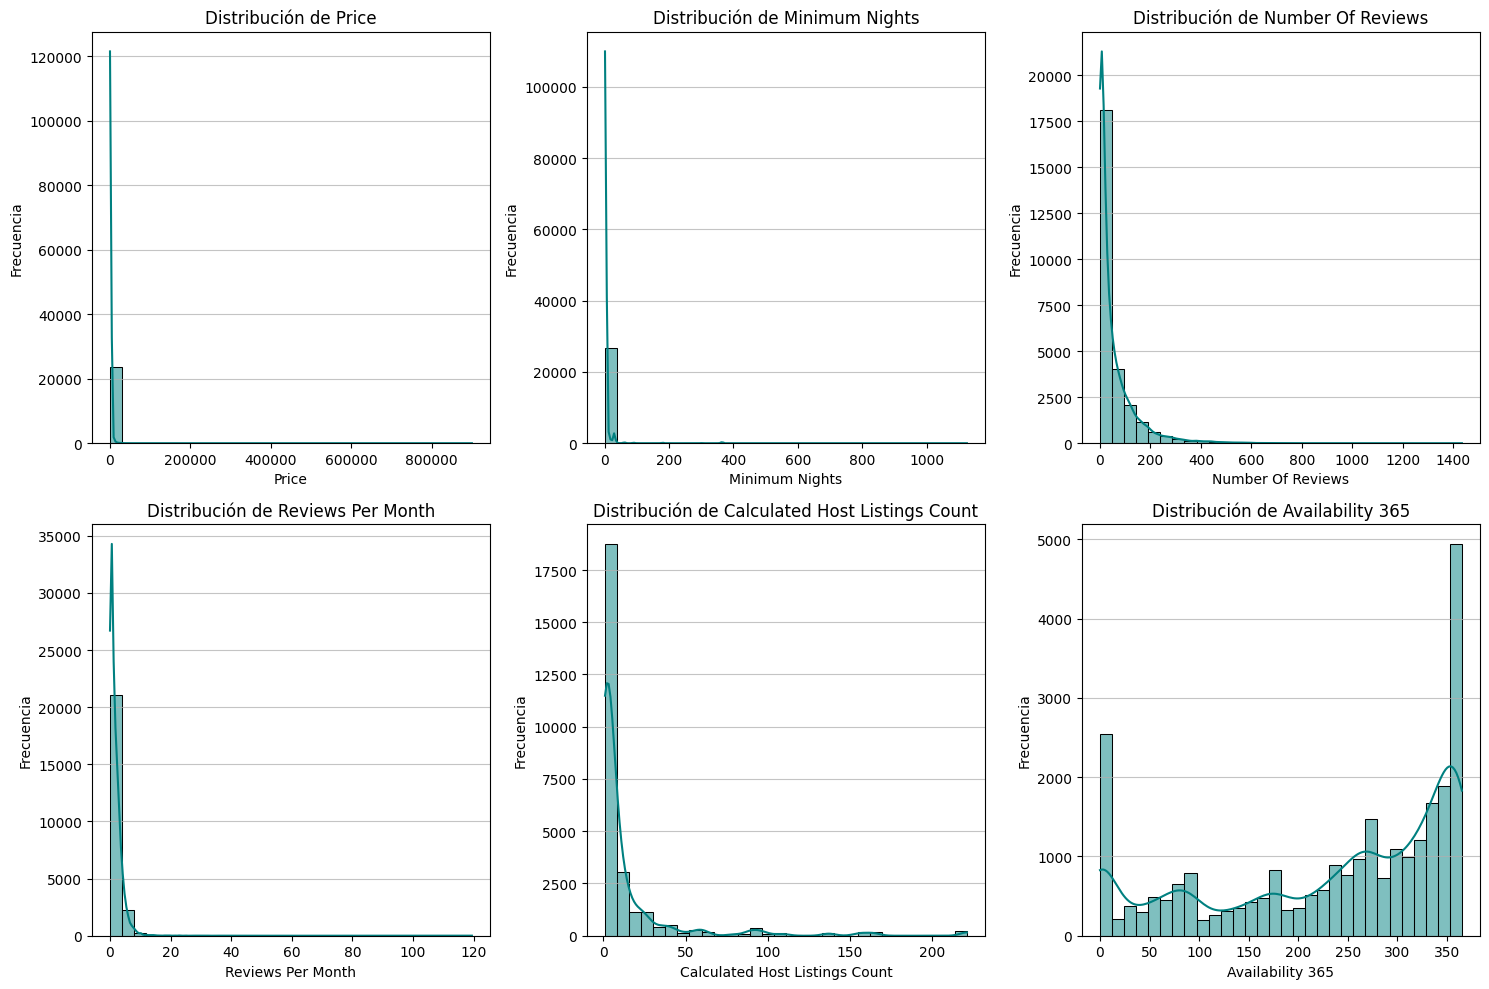

In [99]:
import math

# Observar distribución de las columnas con nulos
num_cols = len(columnas_numericas)
num_rows = math.ceil(num_cols / 3)

plt.figure(figsize=(15, 5 * num_rows))

for i, col in enumerate(columnas_numericas,1):
    plt.subplot(num_rows, 3, i) # Change grid to num_rows x 3
    sns.histplot(data=df_airbnb_cdmx[col], bins=30, kde=True, color = 'teal')
    plt.title(f'Distribución de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

In [100]:
# Calcular media y desviación estándar de las columnas con nulos

media_price = df_airbnb_cdmx['price'].mean()
std_price = df_airbnb_cdmx['price'].std()

media_reviews_per_month = df_airbnb_cdmx['reviews_per_month'].mean()
std_reviews_per_month = df_airbnb_cdmx['reviews_per_month'].std()

lim_sup_price = media_price + std_price
lim_inf_price = media_price - std_price

lim_sup_reviews_per_month = media_reviews_per_month + std_reviews_per_month
lim_inf_reviews_per_month = media_reviews_per_month - std_reviews_per_month

configuracion_price = [(media_price, 'blue'), (lim_sup_price, 'red'), (lim_inf_price, 'red')]
configuracion_reviews_per_month = [(media_reviews_per_month, 'blue'), (lim_sup_reviews_per_month, 'red'), (lim_inf_reviews_per_month, 'red')]

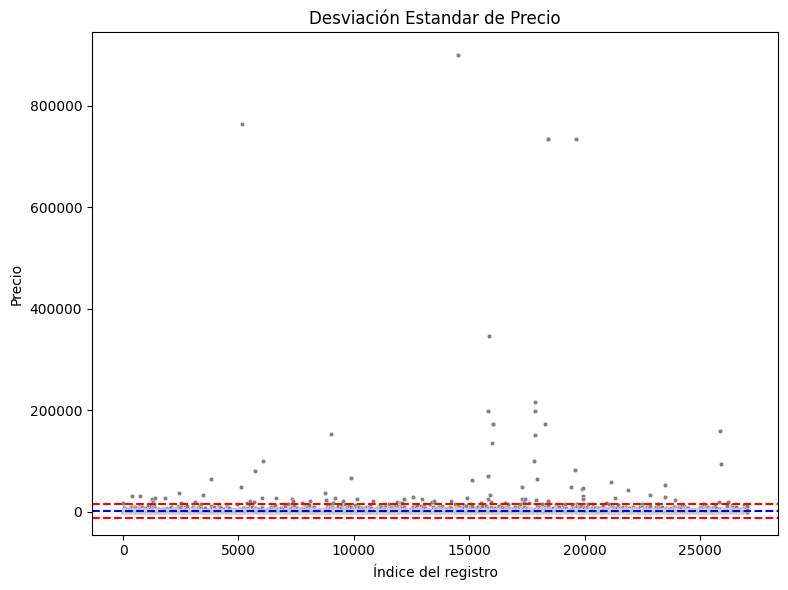

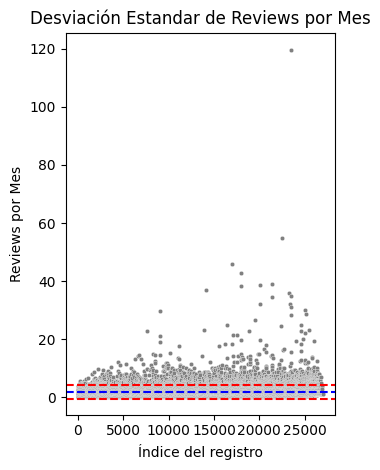

In [101]:
# Observar distribución de las columnas con nulos
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=range(len(df_airbnb_cdmx)), y=df_airbnb_cdmx['price'], s=10, color='gray')
plt.title('Desviación Estandar de Precio')
plt.xlabel('Índice del registro')
plt.ylabel('Precio')
for dato, color in configuracion_price:
    plt.axhline(y=dato, color=color, linestyle='--')
plt.tight_layout()
plt.show()

plt.subplot(1, 2, 2)
sns.scatterplot(x=range(len(df_airbnb_cdmx)), y=df_airbnb_cdmx['reviews_per_month'], s=10, color='gray')
plt.title('Desviación Estandar de Reviews por Mes')
plt.xlabel('Índice del registro')
plt.ylabel('Reviews por Mes')
for dato, color in configuracion_reviews_per_month:
    plt.axhline(y=dato, color=color, linestyle='--')
plt.tight_layout()
plt.show()

**6. Imputación de valores nulos en columnas numéricas y exportación final de datos**

* Sustituye los valores nulos de la columna `price` por la **mediana**.
* Sustituye los valores nulos de la columna `reviews_per_month` por **0**.
* Exporta el dataframe procesado a un archivo CSV llamado `airbnb_clean.csv`.

In [102]:
# Imputación numérica
df_airbnb_cdmx['price'] = df_airbnb_cdmx['price'].fillna(df_airbnb_cdmx['price'].median())
df_airbnb_cdmx['reviews_per_month'] = df_airbnb_cdmx['reviews_per_month'].fillna(0)

In [103]:
 # Crear dataset final
df_airbnb_cdmx.to_csv('airbnb_clean.csv', index=False)